# Backpropagation — How Neural Networks Learn

## Goal
Understand how gradients flow backward through a network.
Backpropagation is the algorithm that makes deep learning possible.

## Key Questions
- What is a gradient and why does it matter?
- How does the chain rule connect layers?
- What happens when gradients vanish or explode?

## What We Build
Step-by-step backpropagation visualization — showing exactly what each gradient means.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. What is a Gradient?
A gradient tells us: "if I change this weight slightly, how much does the loss change?"
- Positive gradient → weight is too high → decrease it
- Negative gradient → weight is too low → increase it
- Zero gradient → weight is at the right value

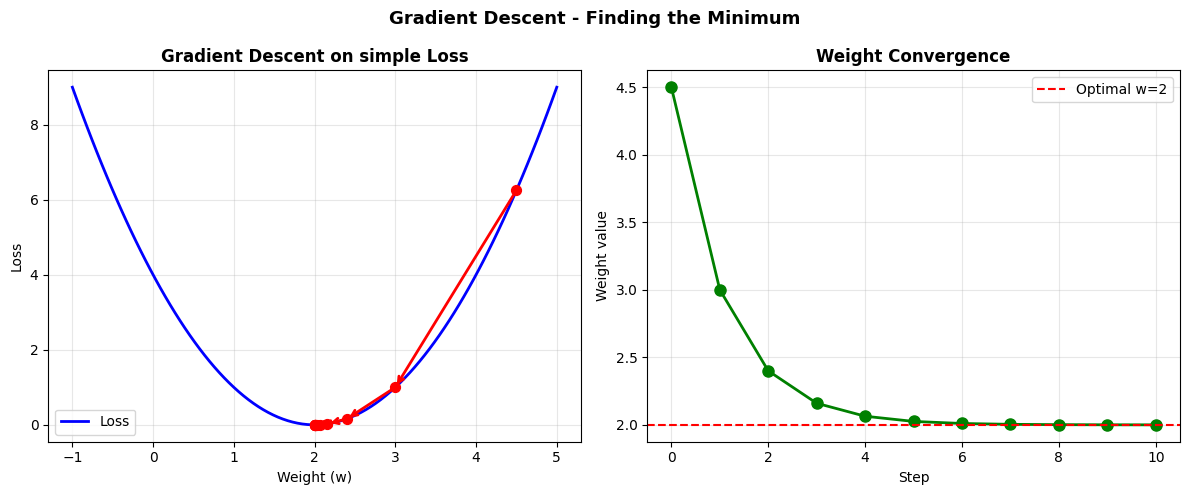

Started at w = 4.5
Ended at w = 2.0003
Optimal w = 2.0


In [2]:
# Simple example - visualize what gradient means
def loss_function(w: float) -> float:
    """Simple parabolic loss - minimum at w=2."""
    return (w - 2) ** 2

def gradient(w: float) -> float:
    """Derivative of loss - tells us which direction to move."""
    return 2 * (w - 2)

w_values = np.linspace(-1, 5, 100)
loss_values = [loss_function(w) for w in w_values]

# Gradient descent simulation
w = 4.5 # start far from minimum
learning_rate = 0.3
history = [w]

for _ in range(10):
    grad = gradient(w)
    w = w - learning_rate * grad
    history.append(w)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Loss landscape with gradient descent steps
axes[0].plot(w_values, loss_values, "b-", linewidth=2, label="Loss")
for i, w_h in enumerate(history[:-1]):
    axes[0].annotate("",
                    xy=(history[i+1], loss_function(history[i+1])),
                    xytext=(w_h, loss_function(w_h)),
                    arrowprops=dict(arrowstyle="->", color="red", lw=2))
axes[0].scatter([w_h for w_h in history],
               [loss_function(w_h) for w_h in history],
               c="red", s=50, zorder=5)
axes[0].set_title("Gradient Descent on simple Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Weight (w)")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2 - Weight convergence
axes[1].plot(history, "g-o", linewidth=2, markersize=8)
axes[1].axhline(2.0, color="red", linestyle="--", label="Optimal w=2")
axes[1].set_title("Weight Convergence", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Weight value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Gradient Descent - Finding the Minimum", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gradient_descent.png", dpi=300)
plt.show()

print(f"Started at w = 4.5")
print(f"Ended at w = {history[-1]:.4f}")
print(f"Optimal w = 2.0")